In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import copy
from torchvision.datasets import ImageFolder
import random
import numpy as np
from torchvision import transforms
import time
import torch.nn as nn
import torchvision.models as models
from PIL import Image

from torchvision.datasets import Flowers102
from torchvision import transforms


In [2]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [3]:
# Fixed global seed for full experiment reproducibility
SEED = 42

# Controls randomness from the `random` module
random.seed(SEED)

# Controls randomness in NumPy operations
np.random.seed(SEED)

# Ensures deterministic behavior for PyTorch CPU operations
torch.manual_seed(SEED)

# DataLoader worker seeding
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [4]:
# Includes data augmentation to improve generalization
train_transform = transforms.Compose([
    
    # Resize the shorter side to 256 pixels
    transforms.Resize(256), #  Shape: (H, W, 3) → (H', W', 3), where min(H', W') = 256

    # Randomly crop and resize to 224×224
    transforms.RandomCrop(224),  # Shape: (H', W', 3) → (224, 224, 3)

    # Random horizontal flip (with probability p=0.5)
    transforms.RandomHorizontalFlip(p = 0.5),
    
    # Random color perturbations (brightness, contrast, saturation, hue)
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),

    # Convert PIL Image to PyTorch Tensor
    # (H, W, C) → (C, H, W), values scaled to [0.0, 1.0]
    transforms.ToTensor(),  # Shape: (224, 224, 3) → (3, 224, 224)

     # Normalize using ImageNet statistics (per channel)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# No random augmentations to ensure deterministic evaluation
val_test_transform = transforms.Compose([

    # Resize the shorter side to 256 pixels
    transforms.Resize(256),   # Shape: (H, W, 3) → (H', W', 3), min(H', W') = 256
    transforms.CenterCrop(224),  # Shape: (H', W', 3) → (224, 224, 3)
    
    transforms.ToTensor(),  # Shape: (224, 224, 3) → (3, 224, 224)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


batch_size = 64
SEED = 42   # or whatever you are using

train_data = datasets.Flowers102(
    root="data",          # same folder style as your previous code
    split="train",
    transform=train_transform,
    download=True    # set to False if already downloaded
)

val_data = datasets.Flowers102(
    root="data",
    split="val",
    transform=val_test_transform,
    download=True
)

test_data = datasets.Flowers102(
    root="data",
    split="test",
    transform=val_test_transform,
    download=True
)

# ────────────────────────────────────────────────
# Optional: deterministic worker seeding (keep if you need it)
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    # numpy / random.seed(worker_seed)   ← add if you use numpy.random in transforms
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ────────────────────────────────────────────────
# DataLoaders — almost identical to your original code

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    generator=g,
    worker_init_fn=seed_worker,

)

val_dataloader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    generator=g,
    worker_init_fn=seed_worker,
  
)

test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    generator=g,
    worker_init_fn=seed_worker,
 
)

In [6]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# ResNet-50's original head: Linear(2048 → 1000)
in_features = model.fc.in_features          # 2048
model.fc = nn.Linear(in_features, 102)      # 2048 → 102

In [7]:
# ── All parameters remain trainable (full fine-tune) ─────────
for param in model.parameters():
    param.requires_grad = True

# Parameter count sanity check
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")   # ~25 M
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 23,717,030
Trainable parameters : 23,717,030


In [8]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

In [10]:
def trainer(train_dataloader,  val_dataloader, model, loss_fn, optimizer, epochs, early_stop_patience, device, 
            scheduler=None, scheduler_type=None, max_norm=1.0
):
    no_improve_epochs = 0

    train_loss = []
    val_loss = []
    train_accuracy = []
    val_accuracy = []

    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")

    model = model.to(device)
 

    for epoch in range(epochs):

        train_batch_loss = 0.0
        val_batch_loss = 0.0

        train_total = 0
        val_total = 0

        train_correct = 0
        val_correct = 0

        model.train()
        

        for X_train, y_train in train_dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad(set_to_none=True)

            pred = model(X_train)
            loss = loss_fn(pred, y_train)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                (p for p in model.parameters() if p.requires_grad),
                max_norm=max_norm
            )

            optimizer.step()

            pred_labels = pred.argmax(dim=1)

            train_batch_loss += loss.item() * y_train.size(0)
            train_total += y_train.size(0)
            train_correct += (pred_labels == y_train).sum().item()

        train_loss.append(train_batch_loss / max(train_total, 1))
        train_accuracy.append(train_correct / max(train_total, 1))

     
        model.eval()
        with torch.no_grad():
            for X_val, y_val in val_dataloader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                pred = model(X_val)
                loss = loss_fn(pred, y_val)

                val_batch_loss += loss.item() * y_val.size(0)

                pred_labels = pred.argmax(dim=1)
                val_correct += (pred_labels == y_val).sum().item()
                val_total += y_val.size(0)

        val_loss.append(val_batch_loss / max(val_total, 1))
        val_accuracy.append(val_correct / max(val_total, 1))

        print(
            f"Epoch [{epoch+1:03d}/{epochs}] | "
            f"Train Loss: {train_loss[-1]:.4f}, "
            f"Train Acc: {train_accuracy[-1]:.4f} | "
            f"Val Loss: {val_loss[-1]:.4f}, "
            f"Val Acc: {val_accuracy[-1]:.4f}"
        )

      
        if val_loss[-1] < best_loss:
            best_loss = val_loss[-1]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, "resnet50_full_finetuning.pth")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

     
        if scheduler is not None:
            if scheduler_type == "plateau":
                scheduler.step(val_loss[-1])
            elif scheduler_type == "epoch":
                scheduler.step()
            else:
                raise ValueError("scheduler_type must be 'plateau' or 'epoch'")

        if no_improve_epochs >= early_stop_patience:
            print(f"Stopped early at epoch: {epoch+1}")
            break

    model.load_state_dict(best_state)

    result = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
    }

    return result


In [12]:
epochs = 40
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)
start_time = time.time()

results = trainer(
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=epochs,
    early_stop_patience=5,
    device=device,
    scheduler=scheduler,
    scheduler_type="epoch",
    max_norm=1.0
)
end_time = time.time()

total_seconds = end_time - start_time
total_minutes = total_seconds / 60

print(f"Total training time: {total_minutes:.2f} minutes")

Epoch [001/40] | Train Loss: 3.9884, Train Acc: 0.2402 | Val Loss: 2.7274, Val Acc: 0.4902
Epoch [002/40] | Train Loss: 2.2055, Train Acc: 0.7676 | Val Loss: 1.8466, Val Acc: 0.7902
Epoch [003/40] | Train Loss: 1.3184, Train Acc: 0.9216 | Val Loss: 1.5060, Val Acc: 0.8559
Epoch [004/40] | Train Loss: 1.0709, Train Acc: 0.9569 | Val Loss: 1.4089, Val Acc: 0.8657
Epoch [005/40] | Train Loss: 0.9984, Train Acc: 0.9755 | Val Loss: 1.5224, Val Acc: 0.8373
Epoch [006/40] | Train Loss: 0.9930, Train Acc: 0.9833 | Val Loss: 1.3853, Val Acc: 0.8500
Epoch [007/40] | Train Loss: 0.9737, Train Acc: 0.9824 | Val Loss: 1.3658, Val Acc: 0.8608
Epoch [008/40] | Train Loss: 0.9527, Train Acc: 0.9873 | Val Loss: 1.3601, Val Acc: 0.8627
Epoch [009/40] | Train Loss: 0.9406, Train Acc: 0.9931 | Val Loss: 1.3079, Val Acc: 0.8804
Epoch [010/40] | Train Loss: 0.9206, Train Acc: 0.9941 | Val Loss: 1.3015, Val Acc: 0.8745
Epoch [011/40] | Train Loss: 0.9202, Train Acc: 0.9912 | Val Loss: 1.2921, Val Acc: 0.8804

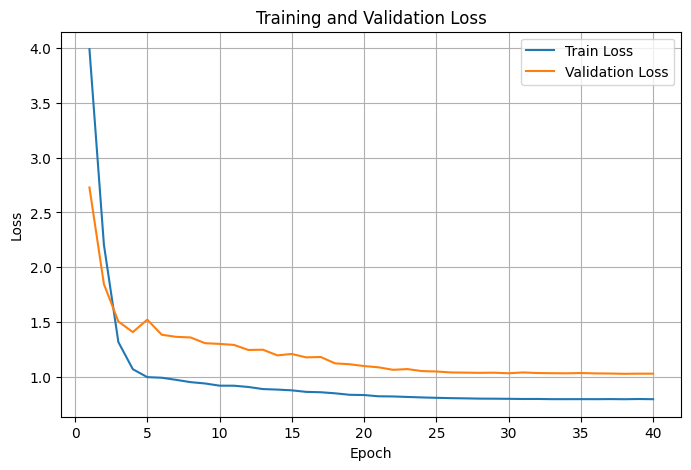

In [13]:
epochs = range(1, len(results["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, results["train_loss"], label="Train Loss")
plt.plot(epochs, results["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


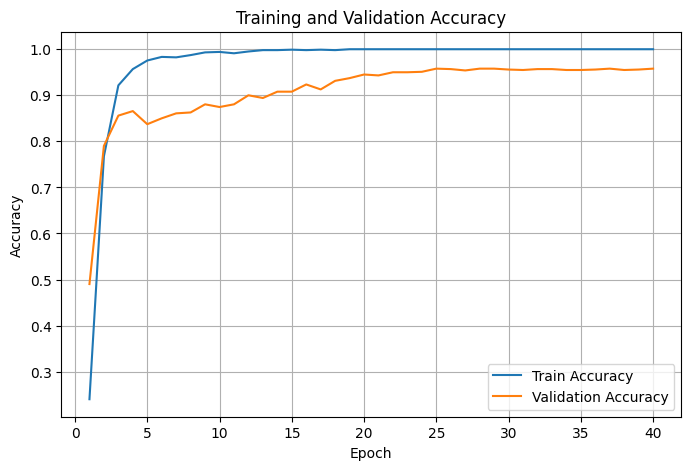

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, results["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, results["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_dataloader:

        images = images.to(device)
        labels = labels.to(device) 

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 94.60%
